# PTM-Mamba Weekly Summary

This notebook documents the PTM-Mamba pipeline in two parts:

1. **Feature extraction** – how we obtain fixed 51×768 PTM-Mamba embeddings for each acet_k window and store them on disk.
2. **Hyperparameter search** – how we searched over CNN+GRU / CNN+BiLSTM classifiers and what we learned from MCC and F1 curves.


## 1. Feature Extraction with PTM-Mamba (NumPy view)

We precomputed PTM-Mamba hidden-state features for each acet_k window and stored them in:

- `features/acet_k/train.csv.gz`
- `features/acet_k/test.csv.gz`

Each row encodes one window and contains:

- metadata: `index`, `Label`, `UniProtID`, `pos`, `seq_len`, `hidden_dim`, `dtype`, `encoding`
- a `features` column containing a compressed representation of a `[seq_len, 768]` tensor:
  - float16 values → raw bytes
  - compressed with zlib
  - base64-encoded for safe storage in CSV

The cell below shows how to decode this back into a fixed **51×768** NumPy array using `numpy`.


In [1]:
import base64
import gzip
import csv
import zlib

import numpy as np

FEATURES_PATH = "features/acet_k/train.csv.gz"
EXPECTED_SEQ_LEN = 51
HIDDEN_DIM = 768

def decode_feature_row(row, expected_seq_len=EXPECTED_SEQ_LEN, hidden_dim=HIDDEN_DIM):
    """Decode one CSV row's `features` field into a fixed [expected_seq_len, hidden_dim] array."""
    # 1) base64-decode, 2) zlib-decompress, 3) interpret as float16
    raw = base64.b64decode(row["features"])
    decomp = zlib.decompress(raw)
    arr = np.frombuffer(decomp, dtype=np.float16)

    # Determine the true sequence length from metadata, then pad/trim to 51
    seq_len = int(row.get("seq_len", expected_seq_len))
    if seq_len * hidden_dim != arr.size:
        # Fallback if metadata and size disagree: infer seq_len from array length
        if arr.size % hidden_dim == 0:
            seq_len = arr.size // hidden_dim
        else:
            raise ValueError(
                f"Unexpected feature size {arr.size} for row index {row.get('index')}"
            )

    # Reshape to [seq_len, hidden_dim]
    mat = arr.reshape(seq_len, hidden_dim).astype(np.float32)

    # Pad or truncate along the sequence axis to get [51, 768]
    if seq_len < expected_seq_len:
        pad_len = expected_seq_len - seq_len
        pad = np.zeros((pad_len, hidden_dim), dtype=np.float32)
        mat = np.concatenate([mat, pad], axis=0)
    elif seq_len > expected_seq_len:
        mat = mat[:expected_seq_len, :]

    return mat

# Inspect a few rows from the train features file
examples = []
with gzip.open(FEATURES_PATH, "rt", newline="") as fh:
    reader = csv.DictReader(fh)
    for i, row in enumerate(reader):
        examples.append((int(row["index"]), int(row["Label"]), decode_feature_row(row)))
        if i >= 2:  # just grab a few
            break

for idx, label, mat in examples:
    print(
        f"Index {idx} | label={label} | shape={mat.shape} | mean={mat.mean():.4f} | std={mat.std():.4f}"
    )


Index 0 | label=1 | shape=(51, 768) | mean=-0.0071 | std=1.0045
Index 1 | label=1 | shape=(51, 768) | mean=-0.0064 | std=1.0046
Index 2 | label=1 | shape=(51, 768) | mean=-0.0022 | std=1.0048


## 2. Hyperparameter Search – MCC and F1

We trained CNN-based classifiers on top of the fixed PTM-Mamba embeddings:

- **CNN+GRU** and **CNN+BiLSTM** architectures.
- Grid over:
  - `model_type ∈ {cnn_gru, cnn_bilstm}`
  - `conv_layers ∈ {1, 2, 3}`
  - `rnn_layers ∈ {1, 2, 3}`
- Each configuration trained for up to 35 epochs with class-weighted cross-entropy and
  metrics (MCC, F1, AUROC, precision, recall, accuracy) computed on a 15% validation split.

The cells below load the saved `config.json` and `metrics_val.json` files from each run,
extract the best validation **MCC** and **F1** per configuration, and visualise how these
metrics change with the depth of the CNN and RNN stacks.


In [2]:
import json
import os
from glob import glob

import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "classifier_runs/acet_k"

records = []

for model_type in ["cnn_gru", "cnn_bilstm"]:
    pattern = os.path.join(BASE_DIR, model_type, "*", "config.json")
    for cfg_path in glob(pattern):
        run_dir = os.path.dirname(cfg_path)
        metrics_path = os.path.join(run_dir, "metrics_val.json")
        if not os.path.exists(metrics_path):
            continue

        with open(cfg_path) as f:
            cfg = json.load(f)
        with open(metrics_path) as f:
            hist = json.load(f)

        # Extract best MCC and corresponding F1 across epochs
        best_mcc = -np.inf
        best_f1 = None
        for rec in hist:
            m = rec["val"].get("mcc", float("nan"))
            f1 = rec["val"].get("f1", float("nan"))
            if m > best_mcc:
                best_mcc = m
                best_f1 = f1

        records.append({
            "model_type": model_type,
            "run_dir": run_dir,
            "conv_layers": cfg.get("conv_layers", 2),
            "rnn_layers": cfg.get("rnn_layers", 1),
            "best_mcc": best_mcc,
            "best_f1": best_f1,
        })

print(f"Loaded {len(records)} runs")
records[:3]


Loaded 15 runs


[{'model_type': 'cnn_gru',
  'run_dir': 'classifier_runs/acet_k/cnn_gru/20260304_090357',
  'conv_layers': 3,
  'rnn_layers': 1,
  'best_mcc': 0.44052335552141264,
  'best_f1': 0.7142550450837268},
 {'model_type': 'cnn_gru',
  'run_dir': 'classifier_runs/acet_k/cnn_gru/20260304_103539',
  'conv_layers': 3,
  'rnn_layers': 3,
  'best_mcc': 0.0,
  'best_f1': 0.6438620295650932},
 {'model_type': 'cnn_gru',
  'run_dir': 'classifier_runs/acet_k/cnn_gru/20260304_073113',
  'conv_layers': 2,
  'rnn_layers': 2,
  'best_mcc': 0.5177401997671577,
  'best_f1': 0.7459098497495826}]

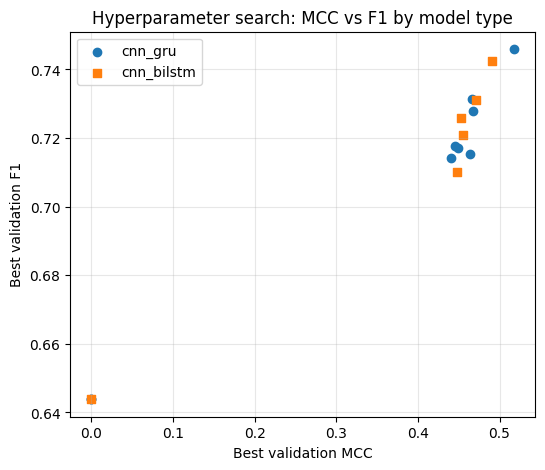

In [3]:
# Scatter plot of best MCC vs best F1 per configuration

fig, ax = plt.subplots(figsize=(6, 5))

for model_type, marker, color in [("cnn_gru", "o", "tab:blue"), ("cnn_bilstm", "s", "tab:orange")]:
    xs = [r["best_mcc"] for r in records if r["model_type"] == model_type]
    ys = [r["best_f1"] for r in records if r["model_type"] == model_type]
    ax.scatter(xs, ys, marker=marker, color=color, label=model_type)

ax.set_xlabel("Best validation MCC")
ax.set_ylabel("Best validation F1")
ax.set_title("Hyperparameter search: MCC vs F1 by model type")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
